<h1 style="color:darkblue; font-size:36px;">Chewing on Change</h1>
<h2 style="color:gray; font-size:24px;">Lesson 4: Using machine learning models to assess variation in fossilized horse teeth for species classification</h2>

# Let's Get Started!

We will explore image classification of upper molar teeth from six horse species representing over 55 million years of the fossil record: Hyracotherium, Mesohippus sp., Parahippus leonensis, Nannippus aztecus, Dinohippus interpolatus, and Equus simplicidens.

To run code in the cells of the notebook, use shift+enter, or the play key at the top. An asterisk will appear at the left of the code and will change to a number once that cell has completed its run. Look in the box under the code to see the output. You do not need to be familiar with every line of code, but notes are included throughout to help you understand the function of each line.

As you work, record your observations in your worksheet.

In [ ]:
# !pip install torchvision  # Uncomment if torchvision is not installed

In [ ]:
# !pip install opencv-python # Uncomment and run if needed

In [ ]:
# !pip install scikit-learn

In [ ]:
# !pip install matplotlib

In [ ]:
# !pip install seaborn

In [ ]:
# !pip install nbconvert

# Section One: Build the Model
We are going to build a model by training it on 55 teeth per class (species) and using 5 unseen teeth per class (species) to test the model's accuracy. Run the following code and record your observations using the worksheet.

In [1]:
# This first bit of code imports the libraries and packages (bundle of different libraries) needed to perform the analysis. 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Set the device to CPU, so that the model can run on your computer
device = torch.device("cpu")

In [3]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

## Load Image Datasets 

In [4]:
# This section loads the datasets of images we will use in our model
import os
import random
from PIL import Image, ImageFilter

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split


# Here we will give names to the folders and images, so that we can keep track of them while we work
base_dir = "Image_Folder"
classes = ["D_interpolatus", "E_simplicidens", "Mesohippus_sp", "N_aztecus", "P_leonensis", "S_sandrae"]

# Here we are setting up the folders the model will look at for training
train_val_dirs = [os.path.join(base_dir, f"{cls}_resized_gray") for cls in classes]

# Here we are setting up the folders the model will look at for testing
test_dirs = [os.path.join(base_dir, f"{cls}_test") for cls in classes]


# We will blur a border around the image to reduce discourage the model from looking at the image backgrounds
class RandomBlurBorders:
    """
    Randomly blur a border band around the image to reduce background reliance.
    - edge_ratio: fraction of H/W used as border width (e.g., 0.12 = 12%)
    - p: probability to apply
    - radius: Gaussian blur radius
    Works on PIL.Image; apply before ToTensor().
    """
    def __init__(self, edge_ratio=0.12, p=0.7, radius=3):
        self.edge_ratio = edge_ratio
        self.p = p
        self.radius = radius

    def __call__(self, img: Image.Image) -> Image.Image:
        
        if random.random() > self.p:
            return img

        if img.mode != 'L':
            img = img.convert('L')

        w, h = img.size
        ew, eh = int(w * self.edge_ratio), int(h * self.edge_ratio)
        blurred = img.filter(ImageFilter.GaussianBlur(self.radius))
        out = img.copy()
        
        out.paste(blurred.crop((0, 0, w, eh)), (0, 0))
        out.paste(blurred.crop((0, h - eh, w, h)), (0, h - eh))

        out.paste(blurred.crop((0, 0, ew, h)), (0, 0))
        out.paste(blurred.crop((w - ew, 0, w, h)), (w - ew, 0))

        return out

# Set up all transforms on the images to get them ready for training and validiation using augmentation + normalization

INPUT_SIZE = 128 

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.80, 1.0), ratio=(0.9, 1.1)),
    transforms.Grayscale(num_output_channels=1),
    RandomBlurBorders(edge_ratio=0.12, p=0.7, radius=3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0),
])

eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

class CustomImageDataset(Dataset):
    def __init__(self, folders, transform=None):
        self.samples = []
        self.transform = transform
        for label, folder in enumerate(folders):
            if not os.path.isdir(folder):
                continue
            if ".ipynb_checkpoints" in folder:
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp')):
                    self.samples.append((os.path.join(folder, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

# Build datasets (two base datasets for different transforms)
# For splitting, we need consistent indexing; so create a base dataset with no transform just to get samples

base_for_split = CustomImageDataset(train_val_dirs, transform=None)
all_samples = base_for_split.samples
all_labels = [label for _, label in all_samples]

# Stratified split
train_idx, val_idx = train_test_split(
    range(len(all_samples)),
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# Now create two datasets with different transforms but same sample list (by reusing base_for_split.samples)
# We wrap a tiny dataset class that uses a shared sample list but distinct transforms

class SharedSamplesDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

train_base = SharedSamplesDataset(all_samples, transform=train_transform)
val_base   = SharedSamplesDataset(all_samples, transform=eval_transform)

# Subsets with the same indices

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(val_base,   val_idx)

# Test dataset reads ONLY the _test folders and uses eval_transform

test_dataset  = CustomImageDataset(test_dirs, transform=eval_transform)

# DataLoaders
batch_size = 32

safe_workers = max(0, min(2, (os.cpu_count() or 2) - 1))

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

# Check the above setup by printing total images for training, validation and test datasets
# Recall we are running this model with 55 images in each of 6 classes, resulting in 330 total training images
# Recall we are also testing it on 5 images in each of 6 classes, resulting in 30 total test images
# Look for these numbers in the output below
print("Total images in training and validation datasets:", len(all_samples))
print("Images in training set:", len(train_dataset))
print("Images in validation set:", len(val_dataset))
print("Images in test set:", len(test_dataset))

Total images in training and validation datasets: 330
Images in training set: 264
Images in validation set: 66
Images in test set: 30


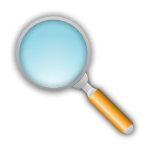

## Define Model Type

Here we are using a SimpleCNN (simple convolusional neural network). This is a model that is very effective for analyzing images, as it automatically learn features from images. As such, CNNs are widely used in tasks where image and video recognition is important.

In [5]:
# Define the CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

In [6]:
# Initialize Model, Loss, Optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
# This line of code sets the learning rate of the model
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train the Model for 10 Epochs 
An epoch is a complete pass of the entire training image dataset through the model. The model will learn from the repetition, and each of the 10 epochs should improve how well it performs.

In [7]:
# Setting up a training loop to have the model repeat for 10 epochs

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)

            val_outputs = model(val_images)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_accuracy:.2f}%")

Epoch [1/10]
  Train Loss: 1.9695, Train Accuracy: 23.48%
  Val Loss:   1.7523, Val Accuracy:   37.88%
Epoch [2/10]
  Train Loss: 1.4025, Train Accuracy: 46.21%
  Val Loss:   1.2356, Val Accuracy:   51.52%
Epoch [3/10]
  Train Loss: 1.0140, Train Accuracy: 60.61%
  Val Loss:   0.7452, Val Accuracy:   74.24%
Epoch [4/10]
  Train Loss: 0.7357, Train Accuracy: 68.94%
  Val Loss:   0.8029, Val Accuracy:   75.76%
Epoch [5/10]
  Train Loss: 0.5516, Train Accuracy: 81.82%
  Val Loss:   0.7369, Val Accuracy:   77.27%
Epoch [6/10]
  Train Loss: 0.5513, Train Accuracy: 78.41%
  Val Loss:   0.2307, Val Accuracy:   89.39%
Epoch [7/10]
  Train Loss: 0.4733, Train Accuracy: 84.09%
  Val Loss:   0.3628, Val Accuracy:   84.85%
Epoch [8/10]
  Train Loss: 0.3837, Train Accuracy: 89.39%
  Val Loss:   0.2460, Val Accuracy:   93.94%
Epoch [9/10]
  Train Loss: 0.2952, Train Accuracy: 91.29%
  Val Loss:   0.3412, Val Accuracy:   89.39%
Epoch [10/10]
  Train Loss: 0.3242, Train Accuracy: 90.53%
  Val Loss:   

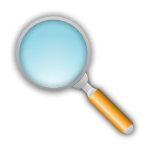

# Section Two: Validate the Model

## We will view a "confusion matrix" on a portion of the training dataset used to validate the model
A confusion matrix shows how well the model does at classifying. The goal is to see our images fall along the diagonal line. Those that don't being misidentified by the model.

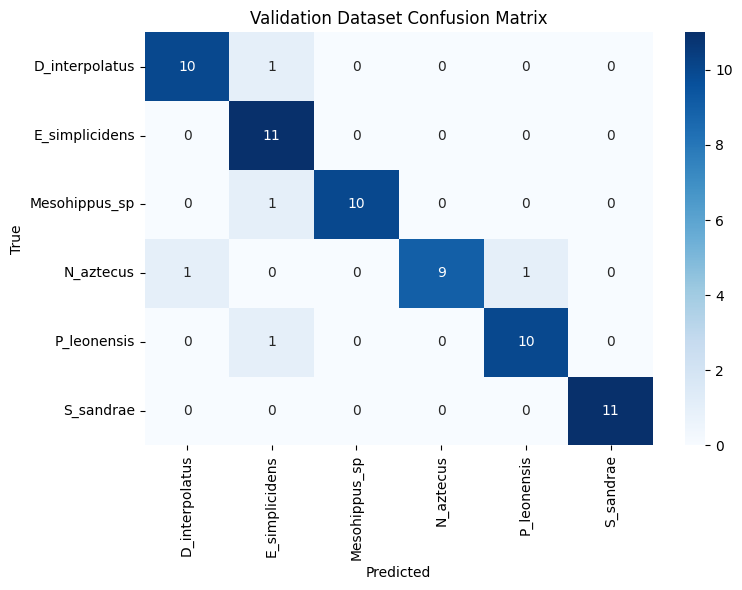

In [8]:
# Setting up the confusion matrix for validation set
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation model
model.eval()
    
# Collect predictions and true labels
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from the datasets. This will label each species with its name
class_names = classes


# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

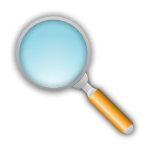

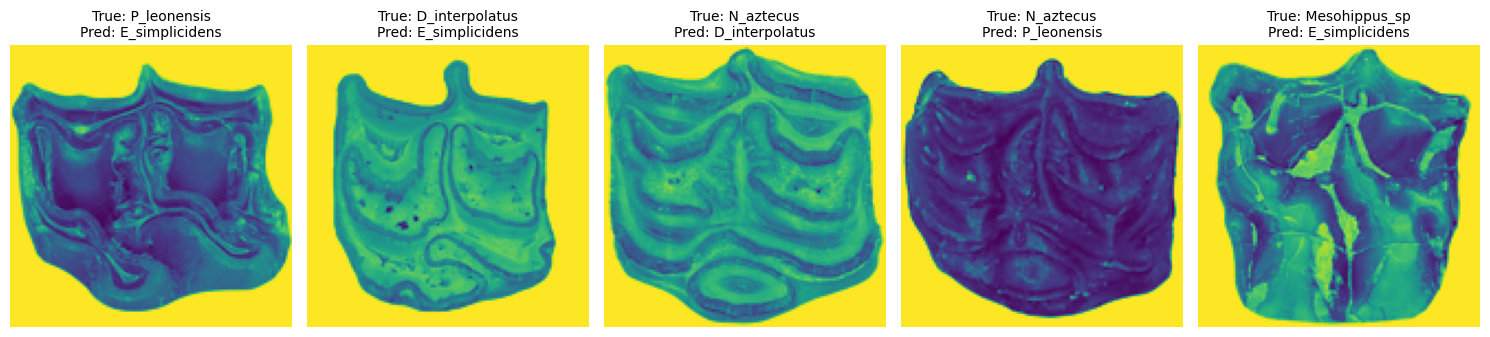

In [9]:
# Now, we will ask to see images of the misclassifed teeth
import matplotlib.pyplot as plt

# Set model to evaluation model
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show up to 10 of the misclassified images
num_to_show = min(10, len(misclassified_images))
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Section Three: Test The Model 

## We can now put the unseen test images into our model

In [10]:
# Now we will test the model with the unseen test data, 5 teeth per class

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Average loss across all batches
test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.3773, Test Accuracy: 90.00%


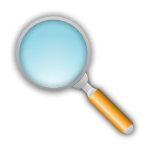

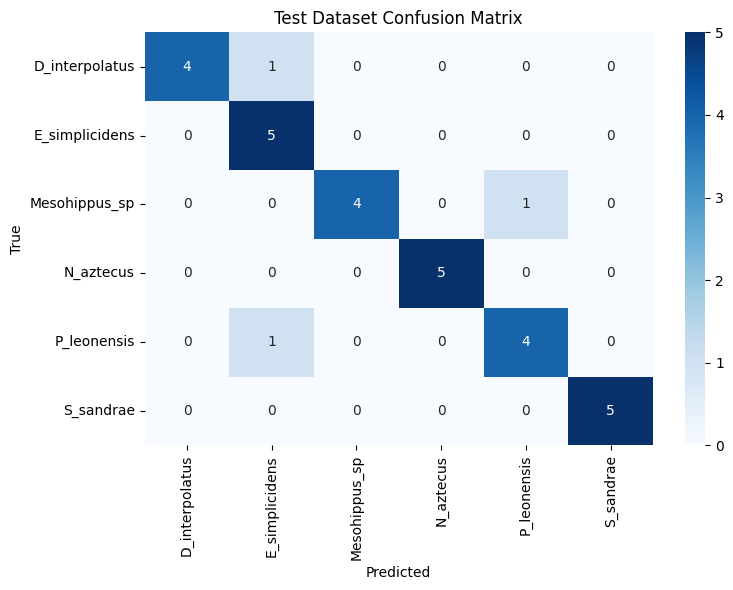

In [11]:
# Confusion matrix for the test dataset results
# Recall that we want to see the results fall along the diagonal line

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset
class_names = classes

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

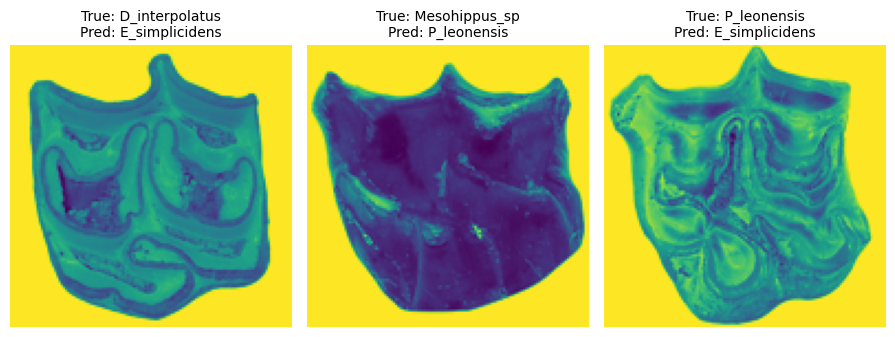

In [12]:
# Show images for misclassifed teeth from the test datasets
import matplotlib.pyplot as plt

# Set model to evaluation model
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show up to 10 of the misclassified images
num_to_show = min(10, len(misclassified_images))
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# This function shows the architecture for our SimpleCNN model

print(model)

SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


## See what features the model used to classify the teeth
This bit of code implements GradCAM. GradCAM stands for Gradient-weighted Class Activation Map, which will create a heatmap of the areas of the image that the model is relying on.

In [14]:
# Set your trained model variable here
model_in_memory = model          

# Keep WEIGHTS_PATH_OVERRIDE unset
WEIGHTS_PATH_OVERRIDE = None

In [ ]:
# Configuration setup
ROOT_IMAGES_DIR        = "Image_Folder"  
INPUT_SIZE             = 128             
USE_GPU_IF_AVAILABLE   = False
OVERRIDE_TARGET_LAYER  = None          
CHANNELS_OVERRIDE      = 1             

# Normalization
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]
MEAN_GRAY = [0.5]
STD_GRAY  = [0.5]

# Background heuristics
EDGE_RATIO       = 0.12
EDGE_THRESH      = 0.55
COM_THRESH_RATIO = 0.28

# Imports and device
import os, math, csv, time
import numpy as np
import torch, torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = 'cuda' if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else 'cpu'
print(f"Device: {device}")
print("CWD:", os.getcwd())

# Utilities
def iter_resized_gray_images_only(root_dir: str):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp')
    for dirpath, _, filenames in os.walk(root_dir):
        if ".ipynb_checkpoints" in dirpath:
            continue
        rel = os.path.relpath(dirpath, root_dir)
        cls = os.path.basename(rel)
        if not cls.endswith("_resized_gray"):
            continue
        for fname in sorted(filenames):
            if fname.lower().endswith(exts):
                yield os.path.join(dirpath, fname)

def load_image_gray(path: str, target_hw=None) -> np.ndarray:
    img = Image.open(path).convert('L')
    if target_hw is not None:
        img = img.resize((target_hw[1], target_hw[0]), Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr[..., None]

def apply_colormap_on_image(img01: np.ndarray, heatmap01: np.ndarray, alpha=0.5) -> np.ndarray:
    cmap = plt.get_cmap('jet')
    colored_hm = cmap(np.clip(heatmap01, 0, 1))[:, :, :3]
    overlay = (1 - alpha) * img01 + alpha * colored_hm
    return np.clip(overlay, 0, 1)

def edge_mass_fraction(heatmap: np.ndarray, edge_ratio: float = EDGE_RATIO) -> float:
    H, W = heatmap.shape
    eh, ew = int(H * edge_ratio), int(W * edge_ratio)
    mask = np.zeros_like(heatmap, dtype=bool)
    mask[:eh, :] = True; mask[-eh:, :] = True; mask[:, :ew] = True; mask[:, -ew:] = True
    total = heatmap.sum() + 1e-8
    return float(heatmap[mask].sum() / total)

def center_of_mass_distance(heatmap: np.ndarray) -> float:
    H, W = heatmap.shape
    y = np.arange(H); x = np.arange(W)
    X, Y = np.meshgrid(x, y)
    mass = heatmap.sum() + 1e-8
    cx = (heatmap * X).sum() / mass
    cy = (heatmap * Y).sum() / mass
    return float(math.hypot(cx - W/2.0, cy - H/2.0))

def flag_background(edge_frac: float, com_dist: float, H: int, W: int,
                    edge_thresh: float = EDGE_THRESH, com_thresh_ratio: float = COM_THRESH_RATIO) -> bool:
    diag = math.hypot(H, W)
    return (edge_frac >= edge_thresh) or (com_dist >= com_thresh_ratio * diag)

def find_module_by_name(model: nn.Module, name: str) -> nn.Module:
    m = model
    for part in name.split('.'):
        if part.isdigit(): m = list(m.children())[int(part)]
        else: m = getattr(m, part)
    return m

def get_last_conv_layer(model: nn.Module):
    last_name, last_module = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module
    if last_module is None:
        raise RuntimeError("No Conv2d layers found. Set OVERRIDE_TARGET_LAYER to a valid conv module path.")
    return last_name, last_module

def infer_input_channels(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            return m.in_channels
    return 3

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module, device: str = 'cuda'):
        self.model = model.to(device).eval()
        self.device = device
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def fwd_hook(module, input, output):
            self.activations = output
        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.fwd_handle = self.target_layer.register_forward_hook(fwd_hook)
        try:
            self.bwd_handle = self.target_layer.register_full_backward_hook(bwd_hook)
        except Exception:
            self.bwd_handle = self.target_layer.register_backward_hook(bwd_hook)

    def generate(self, input_tensor: torch.Tensor, target_class=None):
        input_tensor = input_tensor.to(self.device)
        logits = self.model(input_tensor)
        pred = int(logits.argmax(dim=1).item()) if target_class is None else int(target_class)
        loss = logits[:, pred].sum()
        self.model.zero_grad(set_to_none=True)
        loss.backward(retain_graph=True)

        acts = self.activations
        grads = self.gradients
        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((weights * acts).sum(dim=1, keepdim=True))
        cam_np = cam[0,0].detach().cpu().numpy()
        cam_np = cam_np - cam_np.min()
        cam_np = cam_np / (cam_np.max() + 1e-8)
        return cam_np, pred

# Use in memory model 
model_in_memory = model   

# Resolve target layer
if OVERRIDE_TARGET_LAYER:
    target_layer = find_module_by_name(model_in_memory, OVERRIDE_TARGET_LAYER)
    target_layer_name = OVERRIDE_TARGET_LAYER
else:
    target_layer_name, target_layer = get_last_conv_layer(model_in_memory)

print("Target layer:", target_layer_name)

# Channels & transforms
in_channels = CHANNELS_OVERRIDE or infer_input_channels(model_in_memory)
print(f"Inferred/override input channels: {in_channels}")

if in_channels == 1:
    tfm = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_GRAY, std=STD_GRAY),
    ])
else:
    tfm = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
    ])

# Output directories
OUT_ROOT  = "output"
CAMS_ROOT = os.path.join(OUT_ROOT, "cams")
os.makedirs(CAMS_ROOT, exist_ok=True)
CSV_PATH  = os.path.join(OUT_ROOT, "gradcam_summary.csv")
CSV_CLASS = os.path.join(OUT_ROOT, "gradcam_per_class.csv")

# Run
start = time.time()
n_images, rows = 0, []
gc = GradCAM(model_in_memory, target_layer, device=device)


for img_path in iter_resized_gray_images_only(ROOT_IMAGES_DIR):
    # Prepare model input
    pil = Image.open(img_path)
    pil = pil.convert('L') if in_channels == 1 else pil.convert('RGB')
    input_tensor = tfm(pil).unsqueeze(0)

    # Grad-CAM
    heatmap, pred = gc.generate(input_tensor)

    # Resize heatmap to INPUT_SIZE
    hm_rs = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((INPUT_SIZE, INPUT_SIZE))
    hm01 = np.array(hm_rs).astype(np.float32) / 255.0

    # Base image for overlay
    if in_channels == 1:
        base = load_image_gray(img_path, target_hw=(INPUT_SIZE, INPUT_SIZE))
        base01 = np.repeat(base, 3, axis=2)  # visualize in RGB
    else:
        base01 = load_image_rgb(img_path, target_hw=(INPUT_SIZE, INPUT_SIZE))

    overlay = apply_colormap_on_image(base01, hm01, alpha=0.5)

    # Mirror input structure in output
    rel_dir = os.path.relpath(os.path.dirname(img_path), ROOT_IMAGES_DIR)
    out_dir = os.path.join(CAMS_ROOT, rel_dir)
    os.makedirs(out_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    Image.fromarray((hm01 * 255).astype(np.uint8)).save(os.path.join(out_dir, f"{base_name}_heatmap.png"))
    Image.fromarray((overlay * 255).astype(np.uint8)).save(os.path.join(out_dir, f"{base_name}_overlay.png"))

    # Heuristics
    edge_frac = edge_mass_fraction(hm01, EDGE_RATIO)
    com_dist  = center_of_mass_distance(hm01)
    flagged   = flag_background(edge_frac, com_dist, H=INPUT_SIZE, W=INPUT_SIZE,
                                edge_thresh=EDGE_THRESH, com_thresh_ratio=COM_THRESH_RATIO)

    rows.append([img_path, pred, edge_frac, com_dist, int(flagged)])
    n_images += 1

# Write CSVs
with open(CSV_PATH, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['image_path', 'pred_class', 'edge_mass_fraction',
                'center_of_mass_distance_px', 'flagged_background'])
    w.writerows(rows)

from collections import defaultdict
agg = defaultdict(lambda: {'count':0, 'edge_sum':0.0, 'com_sum':0.0, 'flag_sum':0})
for img_path, pred, edge_frac, com_dist, flagged in rows:
    cls = os.path.basename(os.path.dirname(img_path))
    d = agg[cls]
    d['count'] += 1
    d['edge_sum'] += edge_frac
    d['com_sum']  += com_dist
    d['flag_sum'] += int(flagged)

with open(CSV_CLASS, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['class_folder', 'n_images', 'edge_mass_mean',
                'com_distance_mean_px', 'n_flagged', 'flagged_pct'])
    for cls, d in sorted(agg.items()):
        if d['count'] == 0: continue
        w.writerow([cls, d['count'], d['edge_sum']/d['count'],
                    d['com_sum']/d['count'], d['flag_sum'],
                    d['flag_sum']/d['count']])

elapsed = time.time() - start
print(f"Processed {n_images} images in {elapsed:.1f}s")
print(f"Overlays saved under: {CAMS_ROOT}")
print(f"Per-image CSV: {CSV_PATH}")
print(f"Per-class CSV: {CSV_CLASS}")

In [ ]:

# Show ONLY selected teeth: Original (color) + Overlay side-by-side

import os
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

ROOT_IMAGES_DIR = "Image_Folder"
OVERLAY_ROOT    = os.path.join("output", "cams")

# Your requested selection (species folder names WITHOUT suffixes)
SELECTED = {
    "D_interpolatus": ["1"],
    "E_simplicidens": ["120"],
    "Mesohippus_sp": ["9"],
    "N_aztecus": ["27"],
    "P_leonensis": ["57"],
    "S_sandrae": ["18"],
}

# --- Helpers ---------------------------------------------------------------

def find_overlay_for_selection(species: str, base: str):
    """
    Locate the overlay PNG that corresponds to a given species and base filename.
    Overlays may be saved under cams subfolders named with suffixes like:
      <species>_resized_gray  or  <species>_test
    and filenames like: <base>_overlay.png
    Returns the first match found, else None.
    """
    candidates = [
        os.path.join(OVERLAY_ROOT, f"{species}_resized_gray", f"{base}_overlay.png"),
        os.path.join(OVERLAY_ROOT, f"{species}_test",         f"{base}_overlay.png"),
        os.path.join(OVERLAY_ROOT, species,                    f"{base}_overlay.png"),  # just in case
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p
    return None

def first_existing_with_ext(base_wo_ext, exts=(".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")):
    """Return the first existing file path for base_wo_ext + extension."""
    for ext in exts:
        cand = base_wo_ext + ext
        if os.path.isfile(cand):
            return cand
    return None

def original_path_for_selection(species: str, base: str):
    """
    Map (species, base) -> Image_Folder/<species>/<base>.<ext> (color).
    """
    return first_existing_with_ext(os.path.join(ROOT_IMAGES_DIR, species, base))

# --- Build the list we will show ------------------------------------------

pairs = []  # (species, original_path, overlay_path)
missing = 0

for species, base_list in SELECTED.items():
    for base in base_list:
        orig = original_path_for_selection(species, base)
        ov   = find_overlay_for_selection(species, base)
        if orig is None or ov is None:
            print(f"[WARN] Missing {'original' if orig is None else 'overlay'} for {species}/{base}")
            missing += 1
            # We still append so the figure keeps order; orig may be None (will render placeholder)
        pairs.append((species, orig, ov))

print(f"Prepared {len(pairs)} requested items ({missing} with missing file).")

# --- Plot: Original (left) + Overlay (right) -------------------------------

if len(pairs) == 0:
    raise RuntimeError("Nothing to display—check SELECTED mapping.")

n = len(pairs)
fig, axes = plt.subplots(n, 2, figsize=(10, 3.2 * n), squeeze=False, dpi=120)

for i, (species, orig_path, ov_path) in enumerate(pairs):
    # Left: original color image (or placeholder if missing)
    if orig_path is not None and os.path.isfile(orig_path):
        original_img = Image.open(orig_path).convert("RGB")
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"{species} – Original")
    else:
        axes[i, 0].text(0.5, 0.5, "Original image not found",
                        ha="center", va="center", fontsize=12)
        axes[i, 0].set_facecolor("lightgray")
        axes[i, 0].set_title(f"{species} – Original (missing)")
    axes[i, 0].axis("off")

    # Right: overlay image (or placeholder if missing)
    if ov_path is not None and os.path.isfile(ov_path):
        overlay_img = Image.open(ov_path).convert("RGB")
        cams_cls = os.path.basename(os.path.dirname(ov_path))  # e.g., Mesohippus_sp_test
        axes[i, 1].imshow(overlay_img)
        axes[i, 1].set_title(f"{cams_cls} – Overlay")
    else:
        axes[i, 1].text(0.5, 0.5, "Overlay not found",
                        ha="center", va="center", fontsize=12)
        axes[i, 1].set_facecolor("lightgray")
        axes[i, 1].set_title(f"{species} – Overlay (missing)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# Also print file paths for easy reference
for species, orig_path, ov_path in pairs:
    display(HTML(
        f"<div style='font-family:monospace'>"
        f"Species : {species}<br>"
        f"Original: {orig_path if orig_path else '<i>missing</i>'}<br>"
        f"Overlay : {ov_path if ov_path else '<i>missing</i>'}"
        f"</div>"
    ))

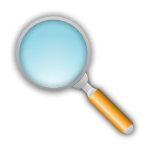

<h1> Congratulations! You just built a model! </h1>


# Section Four: Change a Parameter 

Let's now experiment with the code. Restart the kernel (press the ↻ button above) and choose one parameter from the list below to change and compare your model's overall accuracy. It is best to change only one parameter at a time. If you decide to try multiple changes, be sure to restart the kernel again before running any new change. 

Write down your selection and record your observations on your worksheet. 




### Under "Load Image Datasets" look for the following code:

    DataLoaders
    batch_size = 32

 Try changing the batch size from 32 to 16 or 64 (larger batches will be faster, but also need more memory)

    
    


### Under "Define Model Type" look for the following code:

    class SimpleCNN(nn.Module):
        def __init__(self):
            super(SimpleCNN, self).__init__()
            self.conv_layer = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, kernel_size=3, padding=1)

Try changing the kernel size from 3 to 5 (the larger kernel captures more context but also increases computational needs)


### Under "Define Model Type" look for the following code:
    # Initialize Model, Loss, Optimizer
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    # This line of code sets the learning rate of the model
    optimizer = optim.Adam(model.parameters(), lr=0.001)

Try changing the learning rate (lr) from lr=0.001 to lr=0.01


### Under "Train the Model for 10 Epochs" look for the following code:
    num_epochs = 10
    
Try changing num_epochs = 10 to num_epochs = 20, to run more iterations of the model